# 9 图论

## 9.1 岛屿数量

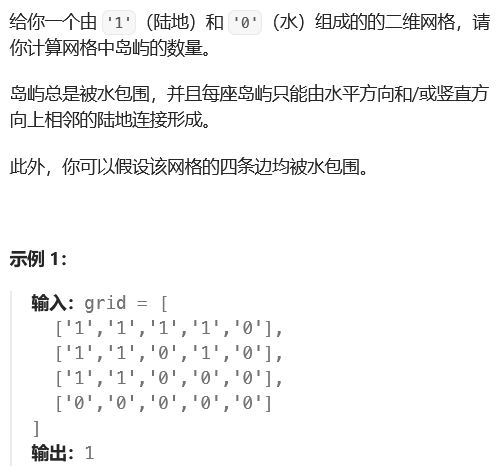

In [ ]:
from typing import List

class Solution:
    def numIslands(self, grid: List[List[str]]) -> int:
        # 空网格边界判断
        if not grid or not grid[0]:
            return 0
        
        rows = len(grid)
        cols = len(grid[0])
        count = 0

        def dfs(r: int, c: int):
            # 递归终止条件：越界 或 当前不是陆地
            if r < 0 or r >= rows or c < 0 or c >= cols or grid[r][c] == '0':
                return
            # 标记为已访问（置为0）
            grid[r][c] = '0'
            # 上下左右四个方向递归搜索
            dfs(r - 1, c)  # 上
            dfs(r + 1, c)  # 下
            dfs(r, c - 1)  # 左
            dfs(r, c + 1)  # 右

        # 遍历整个网格
        for i in range(rows):
            for j in range(cols):
                # 发现新岛屿
                if grid[i][j] == '1':
                    count += 1
                    dfs(i, j)
        return count

## 9.2 腐烂的橘子

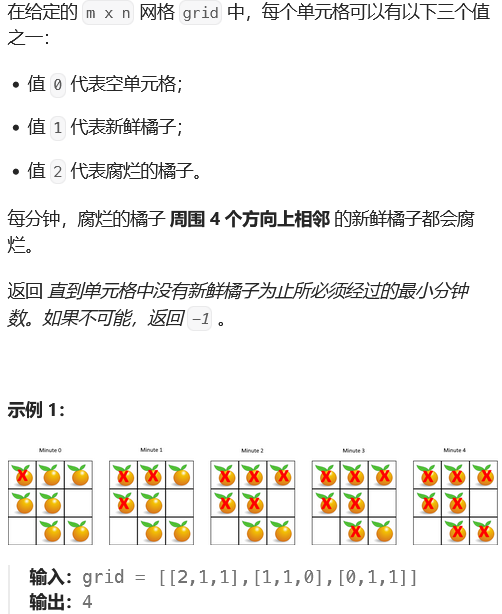

In [ ]:
class Solution:
    def orangesRotting(self, grid: List[List[int]]) -> int:
        # 边界：行、列
        rows = len(grid)
        cols = len(grid[0])
        
        q = deque()  # BFS队列
        fresh = 0    # 新鲜橘子数量
        time = 0     # 腐烂时间
        
        # 第一步：遍历网格，统计新鲜橘子+初始化腐烂橘子队列
        for i in range(rows):
            for j in range(cols):
                if grid[i][j] == 1:
                    fresh += 1
                elif grid[i][j] == 2:
                    q.append((i, j))
        
        # 上下左右四个方向
        dirs = [(-1,0), (1,0), (0,-1), (0,1)]
        
        # 第二步：BFS层序遍历（多源扩散）
        # 有腐烂橘子 + 还有新鲜橘子 才继续传染
        while q and fresh > 0:
            # 一层 = 一分钟
            level_size = len(q)
            for _ in range(level_size):
                x, y = q.popleft()
                # 遍历四个方向
                for dx, dy in dirs:
                    nx = x + dx
                    ny = y + dy
                    # 边界检查 + 是新鲜橘子
                    if 0 <= nx < rows and 0 <= ny < cols and grid[nx][ny] == 1:
                        grid[nx][ny] = 2  # 变腐烂
                        fresh -= 1
                        q.append((nx, ny))
            # 一层遍历完，时间+1
            time += 1
        
        # 还有新鲜橘子没腐烂 → 返回-1，否则返回时间
        return time if fresh == 0 else -1